In [17]:
!pip install pandas numpy matplotlib seaborn scikit-learn transformers torch datasets

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer
from datasets import load_dataset

print("All libraries installed successfully ✅")


All libraries installed successfully ✅


In [36]:
import os
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"


In [37]:
import pandas as pd

human_texts = [
    "I went to the market yesterday and bought fresh vegetables.",
    "My college life has been full of learning and new experiences.",
    "I love spending time with my friends during weekends.",
    "The weather today feels really pleasant and calm.",
    "I am preparing for my exams and focusing on my studies.",
    "Traveling helps me understand different cultures and traditions.",
    "Reading books improves knowledge and imagination.",
    "I enjoy listening to music while working on assignments.",
    "My favorite hobby is painting landscapes.",
    "I feel happy when I achieve my goals through hard work."
]

ai_texts = [
    "Artificial intelligence is transforming industries through automation and data-driven insights.",
    "Machine learning models can analyze vast amounts of data efficiently.",
    "AI systems are capable of generating human-like text responses.",
    "Deep learning has revolutionized computer vision and natural language processing.",
    "AI-powered assistants are becoming common in daily life.",
    "The future of AI includes advancements in healthcare and robotics.",
    "Natural language processing enables machines to understand human language.",
    "AI tools help businesses optimize decision-making processes.",
    "Generative AI models can create text, images, and code.",
    "Artificial intelligence continues to evolve rapidly with new innovations."
]

texts = human_texts + ai_texts
labels = [0]*len(human_texts) + [1]*len(ai_texts)

df = pd.DataFrame({"text": texts, "label": labels})

df

,text,label
0,I went to the market yesterday and bought fres...,0
1,My college life has been full of learning and ...,0
2,I love spending time with my friends during we...,0
3,The weather today feels really pleasant and calm.,0
4,I am preparing for my exams and focusing on my...,0
5,Traveling helps me understand different cultur...,0
6,Reading books improves knowledge and imagination.,0
7,I enjoy listening to music while working on as...,0
8,My favorite hobby is painting landscapes.,0
9,I feel happy when I achieve my goals through h...,0


In [38]:
extra_human = [
    "I enjoy walking alone in the evening.",
    "My favorite place is my hometown.",
    "I like spending time with my cousins during holidays.",
    "Sometimes I just sit and think about life.",
    "I love homemade food more than restaurant food.",
    "My childhood memories are very precious to me.",
    "I like writing in my diary before sleeping.",
    "I enjoy long bus journeys with music.",
    "My best friend always supports me.",
    "I like rainy weather and chai."
] * 2

extra_ai = [
    "Artificial intelligence enables machines to simulate human intelligence.",
    "Machine learning algorithms learn patterns from data.",
    "Deep neural networks are used in modern AI systems.",
    "AI-powered tools improve productivity across industries.",
    "Natural language processing helps machines understand text.",
    "AI is widely used in healthcare and finance.",
    "Intelligent systems rely on large datasets for training.",
    "AI models improve through continuous optimization.",
    "Automation using AI reduces manual effort.",
    "AI-driven insights help businesses grow."
] * 2

df_extra = pd.DataFrame({
    "text": extra_human + extra_ai,
    "label": [0]*len(extra_human) + [1]*len(extra_ai)
})

df = pd.concat([df, df_extra], ignore_index=True)

print("New dataset size:", len(df))

New dataset size: 60


In [39]:
hard_human = [
    "I feel like technology is changing everything slowly.",
    "Sometimes I wonder how AI will affect jobs.",
    "I read an article about AI yesterday and it was interesting.",
    "People talk a lot about automation these days.",
    "I think machines are getting smarter every year."
]

hard_ai = [
    "AI is transforming everyday life in subtle ways.",
    "Many industries are gradually adopting intelligent systems.",
    "Technology continues to reshape human experiences.",
    "Automation is becoming part of daily routines.",
    "Modern tools are increasingly driven by data."
]

df_hard = pd.DataFrame({
    "text": hard_human + hard_ai,
    "label": [0]*len(hard_human) + [1]*len(hard_ai)
})

df = pd.concat([df, df_hard], ignore_index=True)

In [41]:
from sklearn.model_selection import train_test_split

X = df["text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,   # bigger test set
    stratify=y,      # IMPORTANT
    random_state=42
)

In [42]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1,2),
    max_features=500
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [43]:
from sklearn.model_selection import cross_val_score
from sklearn.svm import LinearSVC

svm = LinearSVC()

scores = cross_val_score(svm, X_train_tfidf, y_train, cv=5)

print("Cross-val scores:", scores)
print("Average accuracy:", scores.mean())

Cross-val scores: [0.9 0.7 0.8 0.8 1. ]
Average accuracy: 0.8400000000000001


In [44]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)

print("Improved Accuracy:", accuracy_score(y_test, y_pred))

Improved Accuracy: 0.9523809523809523


In [45]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

balanced_svm = LinearSVC(class_weight="balanced")
balanced_svm.fit(X_train_tfidf, y_train)

balanced_pred = balanced_svm.predict(X_test_tfidf)

print("Balanced SVM Accuracy:", accuracy_score(y_test, balanced_pred))

Balanced SVM Accuracy: 0.9523809523809523


In [46]:
from sklearn.metrics import classification_report

print("Balanced SVM Classification Report:\n")
print(classification_report(y_test, balanced_pred))

Balanced SVM Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.91      0.95        11
           1       0.91      1.00      0.95        10

    accuracy                           0.95        21
   macro avg       0.95      0.95      0.95        21
weighted avg       0.96      0.95      0.95        21



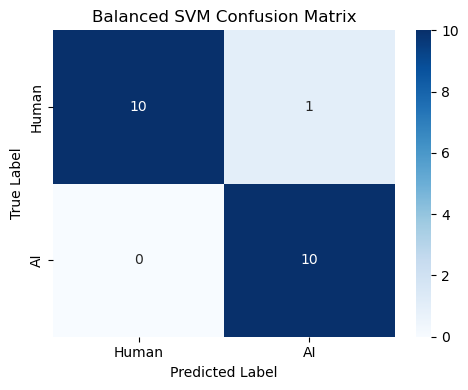

In [47]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, balanced_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Human", "AI"],
            yticklabels=["Human", "AI"])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Balanced SVM Confusion Matrix")
plt.tight_layout()
plt.show()

In [48]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Logistic Regression", "Balanced SVM", "SVM Cross-Val Avg"],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, balanced_pred),
        scores.mean()
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.952381
1,Balanced SVM,0.952381
2,SVM Cross-Val Avg,0.840000


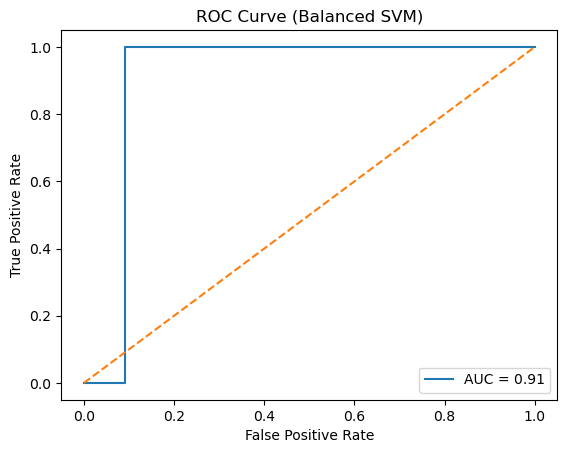

In [49]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Decision scores
y_scores = balanced_svm.decision_function(X_test_tfidf)

fpr, tpr, _ = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Balanced SVM)")
plt.legend()
plt.show()

In [50]:
!pip install tensorflow

   ---------------------------------------- 0.0/332.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/332.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/332.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/332.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/332.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/332.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/332.0 MB ? eta -:--:--
   ---------------------------------------- 0.5/332.0 MB 495.0 kB/s eta 0:11:10
   ---------------------------------------- 0.5/332.0 MB 495.0 kB/s eta 0:11:10
   ---------------------------------------- 0.5/332.0 MB 495.0 kB/s eta 0:11:10
   ---------------------------------------- 0.8/332.0 MB 511.1 kB/s eta 0:10:49
   ---------------------------------------- 1.3/332.0 MB 767.1 kB/s eta 0:07:12
   ---------------------------------------- 1.3/332.0 MB 767.1 kB/s eta 0:07:12
   --------------------

In [51]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

In [52]:
texts = df["text"].values
labels = df["label"].values

In [53]:
max_words = 5000
max_len = 100

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(texts)

sequences = tokenizer.texts_to_sequences(texts)
padded = pad_sequences(sequences, maxlen=max_len, padding="post")

In [54]:
from sklearn.model_selection import train_test_split

X_train_dl, X_test_dl, y_train_dl, y_test_dl = train_test_split(
    padded, labels,
    test_size=0.2,
    stratify=labels,
    random_state=42
)

In [55]:
model = Sequential([
    Embedding(input_dim=max_words, output_dim=64, input_length=max_len),
    LSTM(64, return_sequences=False),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])

model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

model.summary()

C:\Users\Ankita.A.Jalagar\OneDrive\Documents\MLDL\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [56]:
history = model.fit(
    X_train_dl, y_train_dl,
    epochs=8,
    batch_size=8,
    validation_split=0.2,
    verbose=1
)

Epoch 1/8
6/6 ━━━━━━━━━━━━━━━━━━━━ 12s 314ms/step - accuracy: 0.4545 - loss: 0.6935 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 2/8
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 97ms/step - accuracy: 0.4773 - loss: 0.6944 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 3/8
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - accuracy: 0.5455 - loss: 0.6937 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 4/8
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - accuracy: 0.4545 - loss: 0.6961 - val_accuracy: 0.5000 - val_loss: 0.6934
Epoch 5/8
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step - accuracy: 0.5909 - loss: 0.6912 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 6/8
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step - accuracy: 0.5909 - loss: 0.6894 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 7/8
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - accuracy: 0.4318 - loss: 0.6985 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 8/8
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 104ms/step - accuracy: 0.4091 - loss: 0.6974 - val_accuracy: 0.5000 - val_loss: 0.6931


In [57]:
loss, acc = model.evaluate(X_test_dl, y_test_dl)
print("LSTM Test Accuracy:", acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - accuracy: 0.5000 - loss: 0.6931
LSTM Test Accuracy: 0.5


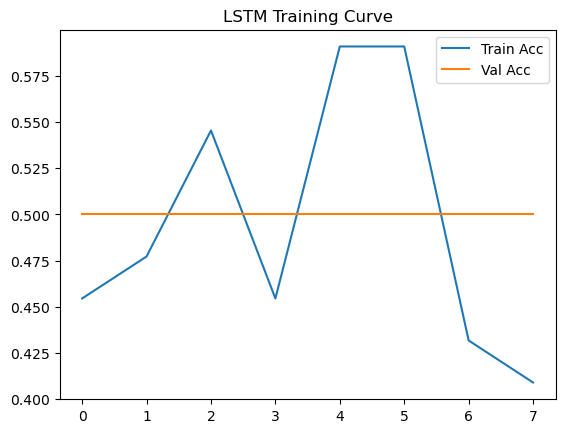

In [58]:
import matplotlib.pyplot as plt

plt.plot(history.history["accuracy"], label="Train Acc")
plt.plot(history.history["val_accuracy"], label="Val Acc")
plt.legend()
plt.title("LSTM Training Curve")
plt.show()